# PCA : 
### Analyse des données urbaines KAGGLE

Dans ce notebook, on va appliquer la méthode PCA afin de projeter les données urbaines multidimensionnelles en 2 dimensions.

L’objectif est de visualiser la structure globale des villes et d’identifier d’éventuels regroupements naturels basés sur des facteurs socio-économiques et environnementaux.

Les résultats seront exportés afin de comparer les résultats avec d’autres méthodes de réduction de dimension


#### Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### Import des données : 

In [6]:
data = pd.read_csv("../data/city_lifestyle_dataset.csv")
data.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [9]:
data.describe()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


Le dataset contient 300 villes décrites par 8 variables numériques et 2 variables qualitatives.

Les variables contiennent les dimensions économiques, environnementales et sociales.  
Les variables présentent des échelles différentes et une variabilité importante des données

Aucune valeur manquante n’est observée.

Dimensions de base : (300, 8)
Dimensions apres standardisation : (300, 8)
Dimensions après PCA : (300, 2)
Variance expliquée par composante :
[0.53805804 0.25833116]
Variance totale expliquée : 0.7963892000125801


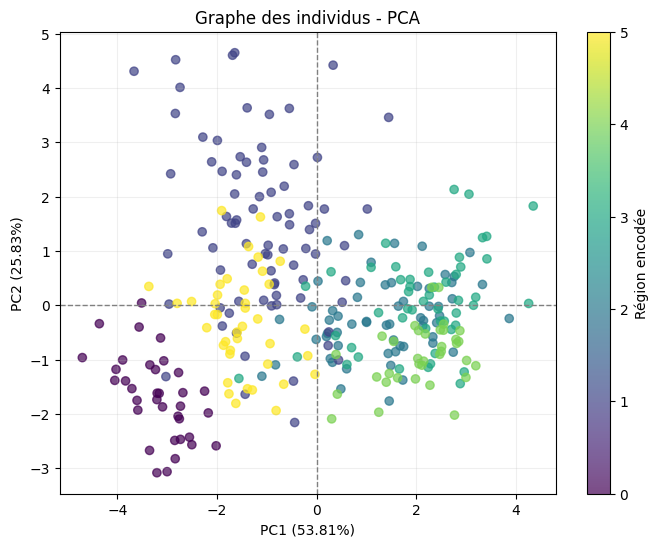

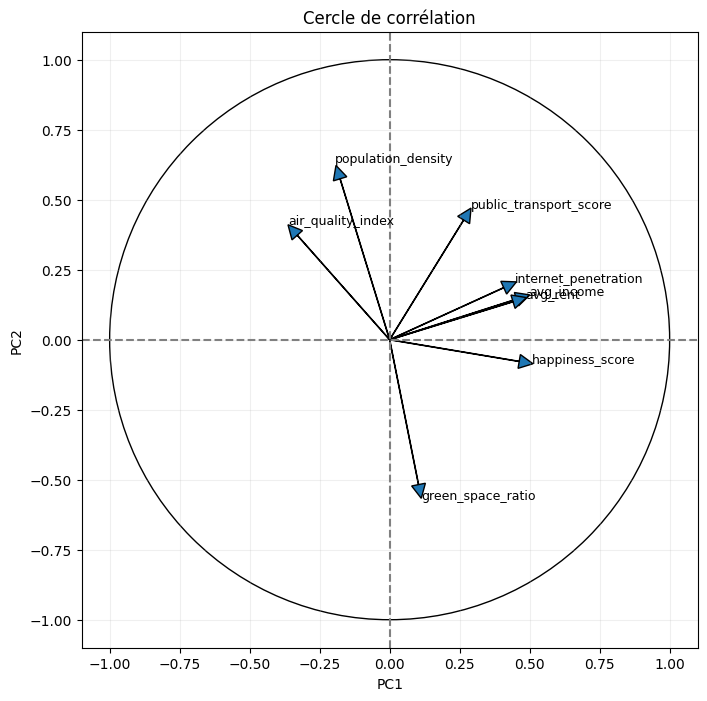

In [15]:
## Selectionner les variables numériques

X = data.select_dtypes(include='number')

print("Dimensions de base :", X.shape)
X.head()


## Standardiser les données

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

print("Dimensions apres standardisation :", X_standard.shape)


## Application de la PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_standard)

print("Dimensions après PCA :", X_pca.shape)


## Variance expliquée 

variance_expl = pca.explained_variance_ratio_

print("Variance expliquée par composante :")
print(variance_expl)

print("Variance totale expliquée :", variance_expl.sum())


## Graphe des individus

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1],
    c=df['country'].astype('category').cat.codes,
    cmap='viridis',
    alpha=0.7
)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)

plt.xlabel(f"PC1 ({variance_expl[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({variance_expl[1]*100:.2f}%)")
plt.title("Graphe des individus - PCA")

plt.colorbar(label="Région encodée")
plt.grid(alpha=0.2)
plt.show()


## afficher le cercle de corrélation

plt.figure(figsize=(8,8))

circle = plt.Circle((0,0), 1, color='black', fill=False)
plt.gca().add_artist(circle)

# Coordonnées des variables (loadings)
loadings = pca.components_.T

for i, feature in enumerate(X.columns):
    plt.arrow(0, 0,
              loadings[i, 0],
              loadings[i, 1],
              head_width=0.05,
              head_length=0.05)
    
    plt.text(loadings[i, 0]*1.1,
             loadings[i, 1]*1.1,
             feature,
             fontsize=9)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle de corrélation")

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(alpha=0.2)
plt.show()


## Analyse des résultats de la PCA

Les deux premières composantes principales expliquent environ 79.6% de la variance totale des données.

Cela signifie que la majorité de l'information contenue dans les 8 variables initiales 
est conservée dans cette représentation en 2 dimensions.

On observe une structuration des villes dans le plan factoriel :

- La 1ere composante est liée aux indicateurs économiques et 
  d'infrastructure
- La 2nd composante montre les dimensions environnementales 
  et de bien-être

Des regroupements apparaissent donc.

La PCA met en evidence une structure cohérente.

In [16]:
## exporter les résultats

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["city_name"] = data["city_name"]
df_pca["country"] = data["country"]

df_pca.to_csv("../outputs/pca_export.csv", index=False)

In [17]:
df_pca.head()

,PC1,PC2,city_name,country
0,1.743192,0.071251,Old Vista,Europe
1,1.641493,-0.014981,Beachport,Europe
2,2.411046,-0.320204,Valleyborough,Europe
3,1.748150,-0.758528,City,Europe
4,3.078707,0.971714,Falls,Europe
